# **Exploratory Data Analysis (EDA)**

---

## Introduction

This exploratory data analysis (EDA) examines customer purchasing behavior, product performance, and sales trends using a cleaned e-commerce dataset analyzed with Python Pandas. The analysis aims to generate insights that support better business and sales decision-making.

### Objectives

- Analyse customer order value distribution and purchasing patterns.
- Segment customers by geographical information to identify regional purchasing differences.
- Examine sales performance across different products.
- Compare the number of orders with items added to carts to identify purchasing trends.
- Investigate the influence of discounts on customer purchases.
- Assess product popularity based on the number of orders containing each product.
- Identify and visualise trends in purchases and sales over time.

---


##### Load required Libraries

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Settings
sns.set_style('dark')

import warnings

#### Load Datset

In [2]:
file_name ='Cleaned_Dataset.xlsx'
df = pd.read_excel(file_name)

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


----

**Helper Columns for Trend Analysis:**

In [4]:
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%B')
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Year'] = df['Date'].dt.year

#### **Overal Key Performance Indicators**

In [5]:
# Sum of Sales
total_revenue = df['TotalPrice'].sum()
print(f'Total Revenue: ${total_revenue:,.2f}')

Total Revenue: $1,264,761.96


In [6]:
# Customer Volume:
total_customers = df['CustomerID'].nunique()
print(f'Total Customers: {total_customers}')

Total Customers: 1189


In [7]:
# Order Volume:
total_orders = df['OrderID'].nunique()
print(f'Total Orders: {total_orders}')

Total Orders: 1200


In [8]:
# Order Value
order_value = total_revenue / total_orders 
print(f'Average Order Value: ${order_value:,.2f}')

Average Order Value: $1,053.97


In [9]:
#Purchase rate
purchase_rate = df['Quantity'].sum() / df['ItemsInCart'].sum() 
print(f'Purchase Rate: {purchase_rate:.2%}')

Purchase Rate: 53.71%


---

#### **How Revenue Has Evolved Over Time**

- Shows overall performance and direction

**1. Revenue By Months**

In [10]:
# Define Correct Month Order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Convert MonthName to Ordered Category
df['MonthName'] = pd.Categorical(
    df['MonthName'],
    categories=month_order,
    ordered=True
)

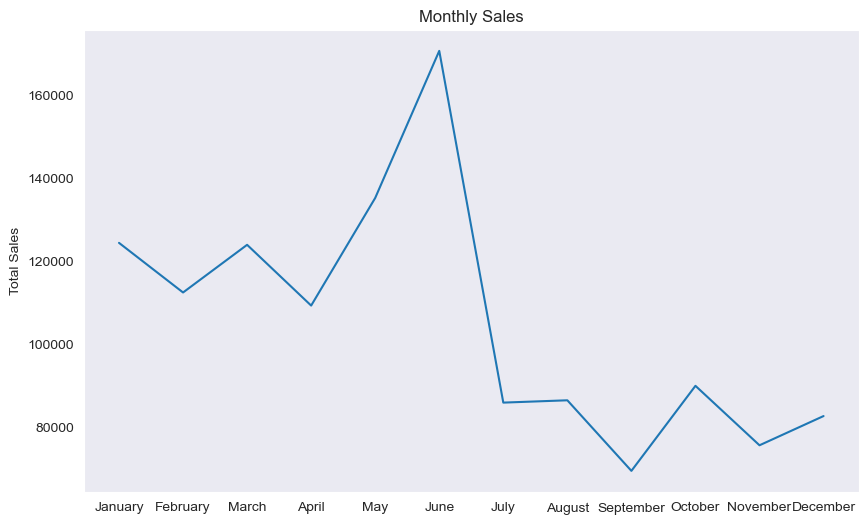

In [22]:
# Group Sale by Month
revenue_trend = df.groupby('MonthName', observed=False)['TotalPrice'].sum().round(2).reset_index()

# Visualize Revenue Trends
plt.figure(figsize=(10,6))    
plt.plot(revenue_trend['MonthName'], revenue_trend['TotalPrice'])
plt.title('Monthly Sales')
plt.ylabel('Total Sales')
plt.show()

----

**2. Weekly Order Performance**

In [12]:
# Define Weekday Name Order
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Convert Weekday Name In Categorical Order
df['DayOfWeek'] = pd.Categorical(
    df['DayOfWeek'],
    categories= days_order,
    ordered=True
)

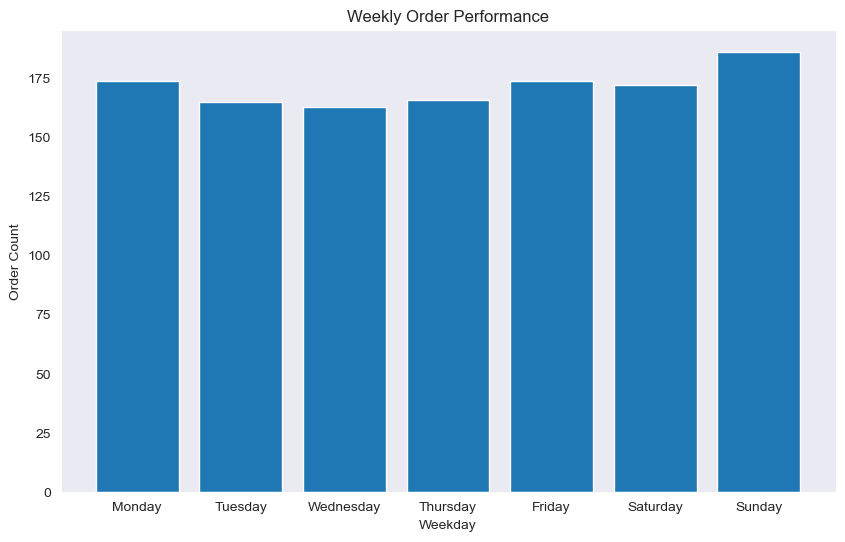

In [13]:
# Group Orders by weekday
weekly_orders = df.groupby('DayOfWeek', observed=False)['OrderID'].nunique().reset_index().sort_values('DayOfWeek')


# Visualize Orders by weekday
plt.figure(figsize=(10,6))
plt.bar(weekly_orders['DayOfWeek'],weekly_orders['OrderID'])

plt.title('Weekly Order Performance')
plt.xlabel('Weekday')
plt.ylabel('Order Count')
plt.show()

----

#### **Drivers of Performance**

- Key contributors

**1. Revenue by Location**

In [14]:
# Group sales by Address
location_sales = df.groupby('ShippingAddress')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
location_sales.rename(columns={'ShippingAddress':'LocationAddress','TotalPrice':'SumRevenue'}, inplace=True)
location_sales.head(10)

,LocationAddress,SumRevenue
0,533 Main St,7753.73
1,558 Main St,7527.40
2,740 Main St,6761.84
3,747 Main St,6700.24
4,811 Main St,6668.36
5,160 Main St,6536.79
6,552 Main St,6521.03
7,619 Main St,6380.38
8,922 Main St,6367.75
9,165 Main St,6161.45


**2. Product Driving Most Order and Revenue**


In [15]:
# Group Orders by Product, aggregate Sales and  Order
order_value = df.groupby('Product').agg({'OrderID':'nunique','TotalPrice':'sum'}).sort_values(by='TotalPrice', ascending =False).reset_index()

order_value = order_value.rename(columns={'OrderID':'OrderCounts','TotalPrice':'SumSales'})
order_value

,Product,OrderCounts,SumSales
0,Chair,178,195620.11
1,Printer,181,195612.61
2,Laptop,173,192126.56
3,Tablet,179,186568.95
4,Monitor,163,175651.41
5,Desk,170,167459.93
6,Phone,156,151722.39


----

#### **Customer Behavior**

- To understand how customers interact, revealing behaviour patterns

**1. Where Are Our Customer Coming From?**

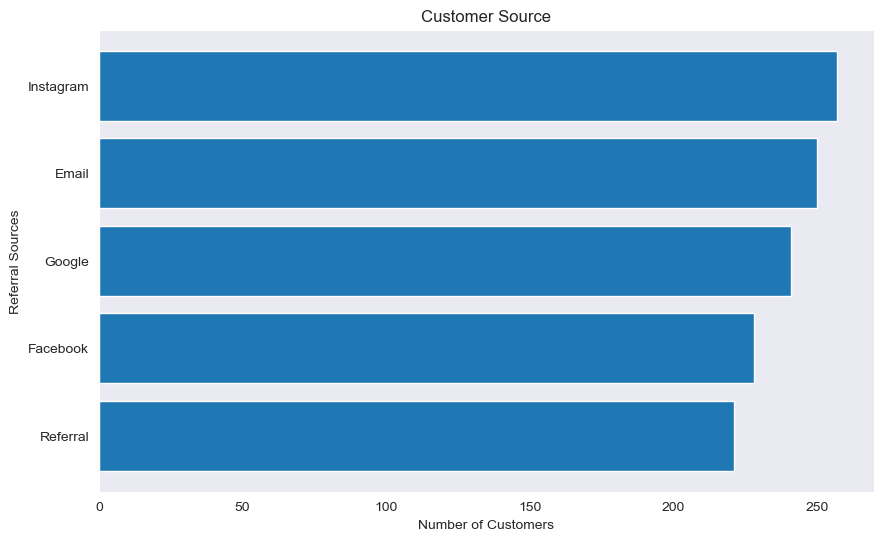

In [16]:
# Group Customer Count by Referral Source
traffic = df.groupby('ReferralSource')['CustomerID'].nunique().sort_values(ascending=True).reset_index()

# Visualize as a bar chart
plt.figure(figsize=(10,6))
plt.barh(traffic['ReferralSource'],traffic['CustomerID'])

plt.title('Customer Source')
plt.xlabel('Number of Customers')
plt.ylabel('Referral Sources')
plt.show()

**2.How Do Customers Prefer to Pay?** 


In [17]:
# Categorise number of customers by payment method
payment_method = df.groupby('PaymentMethod').agg({'CustomerID':'count'}).sort_values(by='CustomerID',ascending=False).reset_index()
payment_method.rename(columns={'CustomerID':'NumberOfCustomers'},inplace=True)
payment_method                                    

,PaymentMethod,NumberOfCustomers
0,Online,258
1,Cash,246
2,Credit Card,234
3,Debit Card,232
4,Gift Card,230


**3. Customer spending distribution**
- That is the spending variability:

In [18]:
# Total Spending per Customer
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum().round(2).reset_index()
customer_spending.rename(columns={'TotalPrice':'TotalSpent'}, inplace=True)

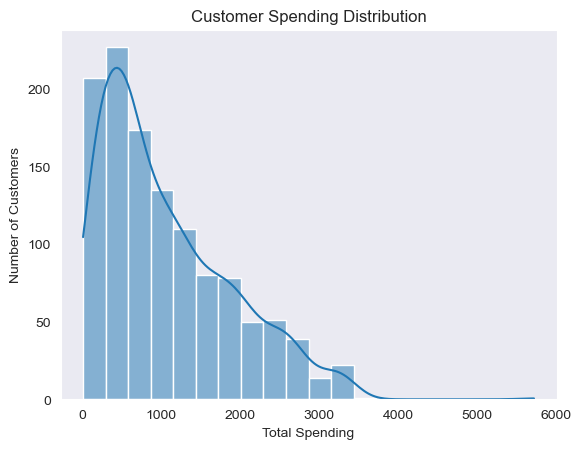

In [19]:
# Visualize Customer Spendings
sns.histplot(customer_spending['TotalSpent'],bins=20,kde=True)
plt.title('Customer Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')
plt.show()

----

#### **Operational Performance**
- Monitor efficiency and fulfillment
- And, assess pricing and promotion impact

**1. Orders Status across the Pipeline?**

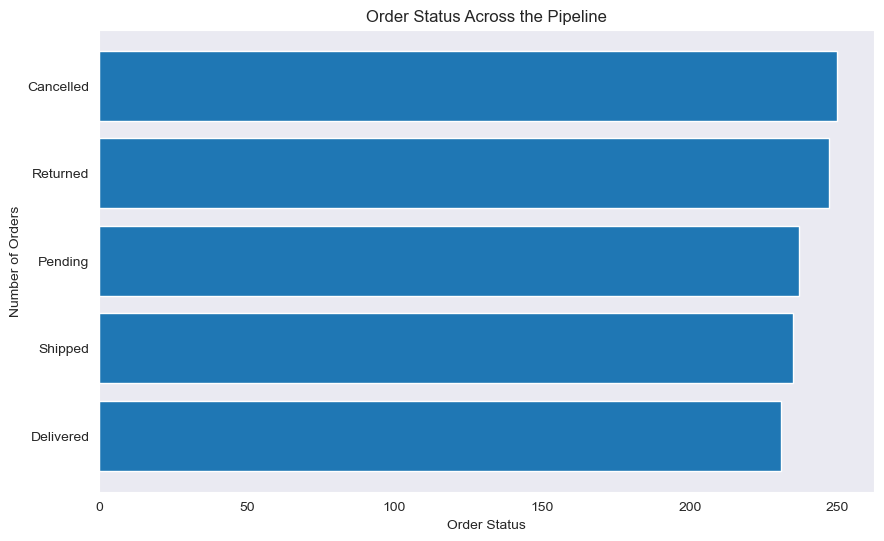

In [20]:
# Categorise Order status
orders_status = df.groupby('OrderStatus')['OrderID'].nunique().sort_values(ascending=True).reset_index()

# Visualize order status
plt.figure(figsize=(10,6))
plt.barh(orders_status['OrderStatus'],orders_status['OrderID'])

plt.title('Order Status Across the Pipeline')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.show()

**2. How Often Are Discounts Used in Orders?**

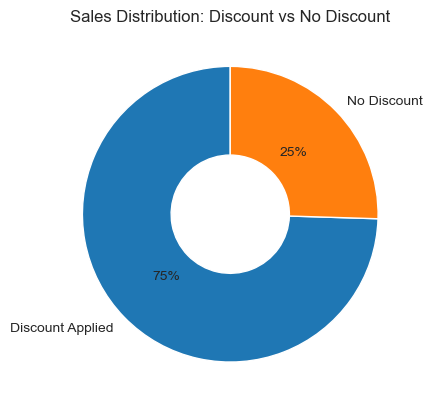

In [21]:
# Identify Discount Usage
df['UsedCoupon'] = np.where(df['CouponCode'] == 'No Coupon',
                            'No Discount', 
                            'Discount Applied')

# Average Order value with Coupon
discount_anlysis = df.groupby('UsedCoupon')['TotalPrice'].sum()

# Visualize discount impact
plt.pie(
    discount_anlysis,
    labels = discount_anlysis.index,
    autopct='%1.0f%%',
    startangle = 90,
    wedgeprops={'width':0.6}
)
plt.title('Sales Distribution: Discount vs No Discount')
plt.show()